In [1]:
import os
import sys
import warnings

import IPython
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.preprocessing import (
    LabelEncoder,
    label_binarize,
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer
)

import lightgbm as lgb

warnings.filterwarnings("ignore")


In [2]:
_base = os.getcwd()
_project_root = (
    os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
)
ALL_EMOTIONS_CSV = os.path.normpath(
    os.path.join(_project_root, "dataset", "all_emotions.csv")
)

print("CSV path:", ALL_EMOTIONS_CSV)
print("Exists:", os.path.isfile(ALL_EMOTIONS_CSV))

RANDOM_STATE = 42
TEST_SIZE = 0.2
OPTUNA_TRIALS = 60
CV_SPLITS = 5


CSV path: d:\Code\Python\Emotion_detecting\dataset\all_emotions.csv
Exists: True


In [3]:
df = pd.read_csv(ALL_EMOTIONS_CSV)
print("Shape:", df.shape)

# Target column in CSV is lowercase 'label' (RF.md names it Label)
TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

print("\n--- Null counts (top 15) ---")
nulls = df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0].head(15) if nulls.max() > 0 else "No nulls")

print("\n--- Duplicated rows ---", df.duplicated().sum())

print("\n--- Label distribution ---")
print(df[TARGET_COL].astype(str).value_counts(dropna=False))


Shape: (54485, 49)

--- Null counts (top 15) ---
No nulls

--- Duplicated rows --- 0

--- Label distribution ---
label
fear       9315
anger      9315
happy      9315
disgust    9315
sad        9310
neutral    7915
Name: count, dtype: int64


In [40]:
FEATURE_COLS = ["F0_mean", "F0_std", "F0_range", 
                "Energy_ mean", "Energy_ std",
                "ZCR_mean", "ZCR_std",
                "Spectral_centroid_mean", "Spectral_centroid_std", "Spectral_flux_mean",
                "MFCC_C0_mean", "MFCC_C1_mean", "MFCC_C2_mean", "MFCC_C3_mean", "MFCC_C4_mean", "MFCC_C5_mean", "MFCC_C6_mean", "MFCC_C7_mean", "MFCC_C8_mean", "MFCC_C9_mean", "MFCC_C10_mean",
                "MFCC_C0_std", "MFCC_C1_std", "MFCC_C2_std", "MFCC_C3_std", "MFCC_C4_std", "MFCC_C5_std", "MFCC_C6_std", "MFCC_C7_std", "MFCC_C8_std", "MFCC_C9_std", "MFCC_C10_std",
                "Delta_MFCC_C0_mean", "Delta_MFCC_C1_mean", "Delta_MFCC_C2_mean", "Delta_MFCC_C3_mean", "Delta_MFCC_C4_mean", "Delta_MFCC_C5_mean",
                "Delta_MFCC_C0_std", "Delta_MFCC_C1_std", "Delta_MFCC_C2_std", "Delta_MFCC_C3_std", "Delta_MFCC_C4_std", "Delta_MFCC_C5_std"]

TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

missing_feat = [c for c in FEATURE_COLS if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing feature columns: {missing_feat[:5]} ...")

# Drop rows with invalid target
_df = df.dropna(subset=[TARGET_COL]).copy()
_df = _df[_df[TARGET_COL].astype(str).str.strip().str.lower() != "nan"]

X = _df[FEATURE_COLS].copy()
y_label = _df[TARGET_COL].astype(str).str.strip()

print("X shape:", X.shape)
print("y unique:", sorted(y_label.unique()))


X shape: (54485, 44)
y unique: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']


In [31]:
# NaN / Inf in features -> median imputation (per column), no StandardScaler (RF.md)
X_proc = X.copy()
for c in FEATURE_COLS:
    s = pd.to_numeric(X_proc[c], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median()
    if pd.isna(med):
        med = 0.0
    X_proc[c] = s.fillna(med)

rem_nan = X_proc.isna().sum().sum()
rem_inf = np.isinf(X_proc.select_dtypes(include=[np.number]).values).sum()
print("Remaining NaN cells:", int(rem_nan), "| inf:", int(rem_inf))
X = X_proc


Remaining NaN cells: 0 | inf: 0


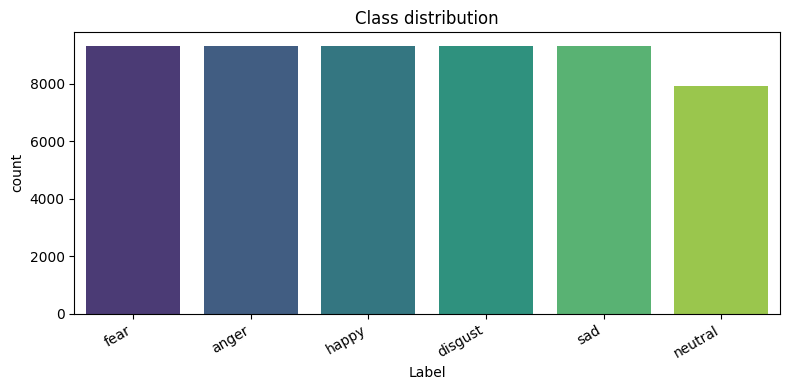

In [41]:
plt.figure(figsize=(8, 4))
order = y_label.value_counts().index.tolist()
sns.countplot(data=pd.DataFrame({"Label": y_label}), x="Label", order=order, palette="viridis")
plt.title("Class distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


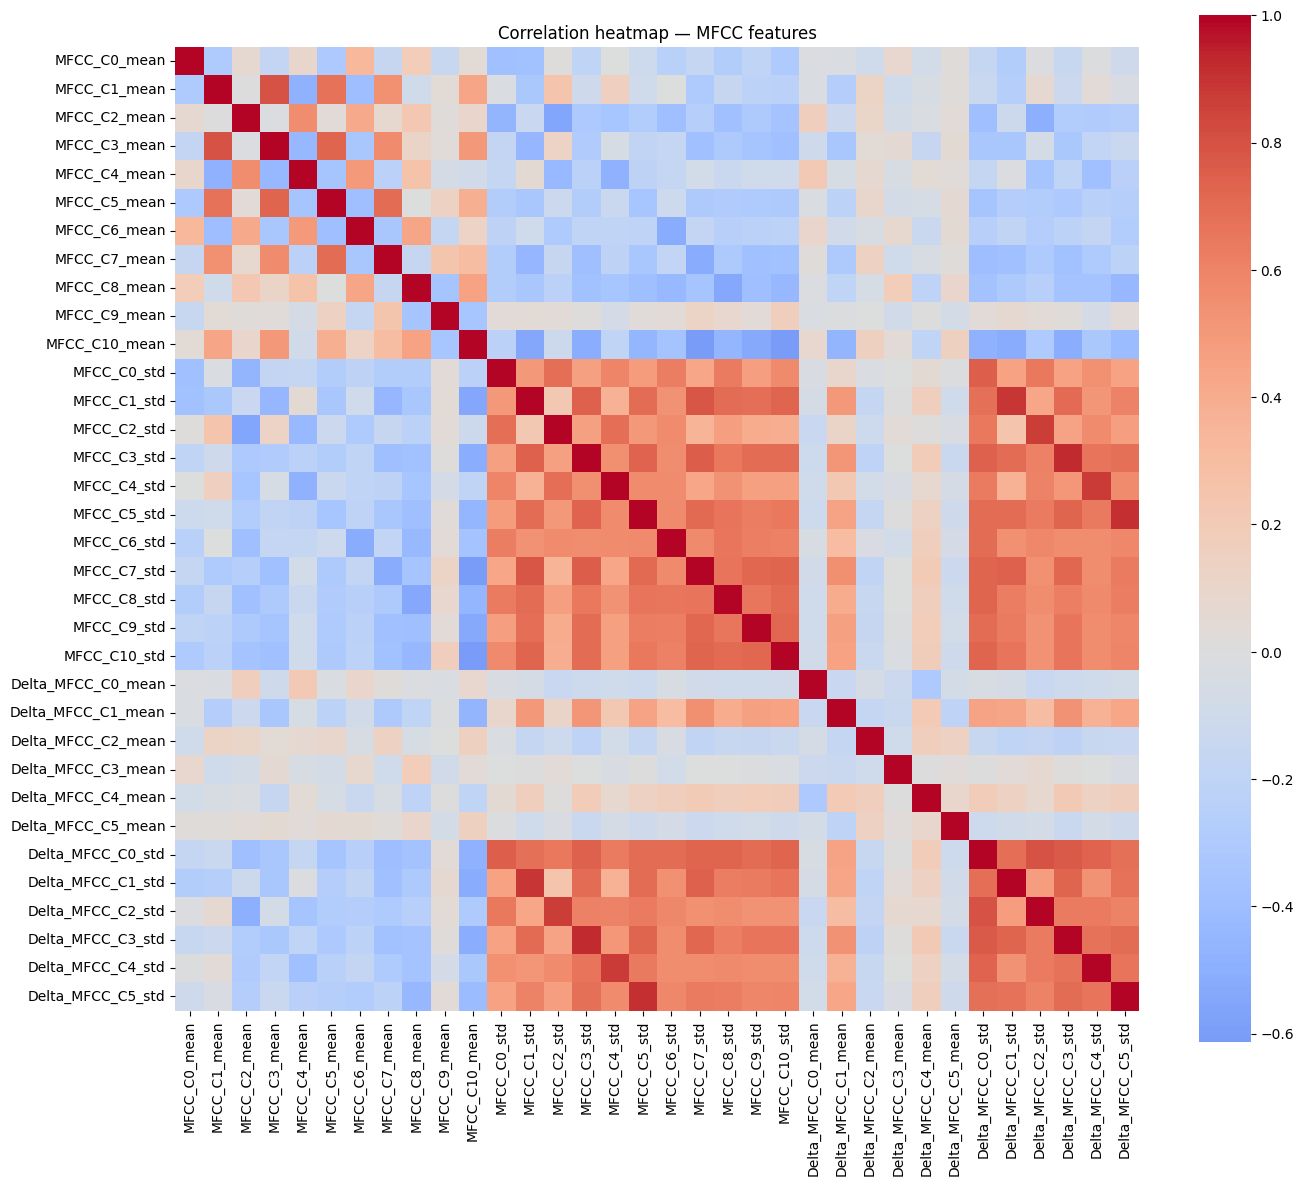

In [42]:
mfcc_cols = [c for c in FEATURE_COLS if "MFCC" in c]
cm = X[mfcc_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap — MFCC features")
plt.tight_layout()
plt.show()


In [43]:
le = LabelEncoder()
y = le.fit_transform(y_label)


print("label_id -> label_name:")
for i, name in enumerate(le.classes_):
    print(f"  {i} -> {name}")

X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y,
    test_size=0.125,
    stratify=y,
    random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)


label_id -> label_name:
  0 -> anger
  1 -> disgust
  2 -> fear
  3 -> happy
  4 -> neutral
  5 -> sad
Train: (47674, 44) Test: (6811, 44)


In [ ]:
CV_SPLITS = 5
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def objective_lgb(trial):
    global y_pred, y_pred_proba

    params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'n_estimators': trial.suggest_int('n_estimators', 585, 610),
        'learning_rate': trial.suggest_float('learning_rate', 0.06, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 225, 250),
        'max_depth': trial.suggest_int('max_depth',-1 , 3, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 75, 80),
        'subsample': trial.suggest_float('subsample', 0.9, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 9e-5, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 9e-5, log=True),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1
    }
    
    clf = lgb.LGBMClassifier(**params, class_weight='balanced')
    clf.fit(X_train_scaled, y_train)

    # assign globals so the notebook can access predictions after each trial
    y_pred = clf.predict(X_test_scaled)
    if hasattr(clf, 'predict_proba'):
        y_pred_proba = clf.predict_proba(X_test_scaled)
    else:
        y_pred_proba = None

    f1w = f1_score(y_test, y_pred, average="weighted")

    return float(f1w)

In [45]:
OPTUNA_TRIALS = 50
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective_lgb, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print("Best value (CV mean F1 weighted):", study.best_value)
print("Best params:", study.best_params)
best_params = study.best_params.copy()




[I 2026-05-30 16:45:30,865] A new study created in memory with name: no-name-ceaabb03-41d3-4c85-80d0-49f51b639b21


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-30 16:45:56,211] Trial 0 finished with value: 0.8793393315504395 and parameters: {'n_estimators': 594, 'learning_rate': 0.0975137887242343, 'num_leaves': 244, 'max_depth': -1, 'min_data_in_leaf': 78, 'subsample': 0.9156018640442437, 'colsample_bytree': 0.8311989040672406, 'reg_alpha': 1.1361243078042788e-05, 'reg_lambda': 6.707213008858893e-05}. Best is trial 0 with value: 0.8793393315504395.
[I 2026-05-30 16:46:22,026] Trial 1 finished with value: 0.8816652648460662 and parameters: {'n_estimators': 600, 'learning_rate': 0.0861462280455262, 'num_leaves': 225, 'max_depth': -1, 'min_data_in_leaf': 80, 'subsample': 0.9832442640800422, 'colsample_bytree': 0.8424678221356553, 'reg_alpha': 1.4910943101314157e-05, 'reg_lambda': 1.4962783074537741e-05}. Best is trial 1 with value: 0.8816652648460662.
[I 2026-05-30 16:46:49,195] Trial 2 finished with value: 0.8784148441742384 and parameters: {'n_estimators': 592, 'learning_rate': 0.07844545901841157, 'num_leaves': 236, 'max_depth': -

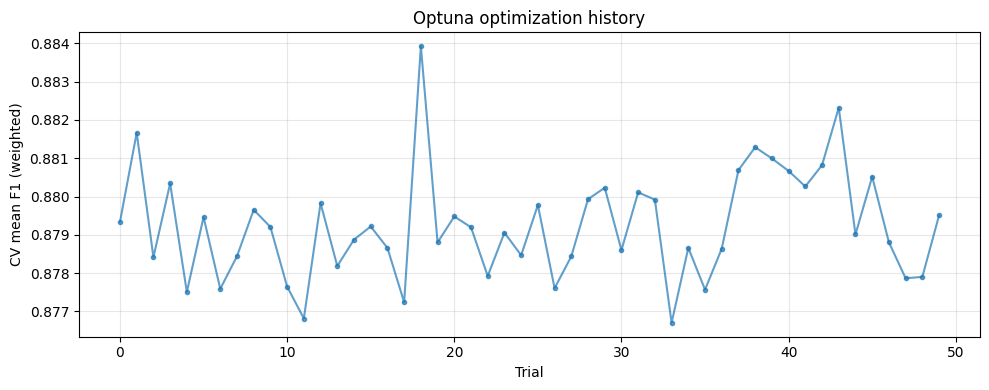

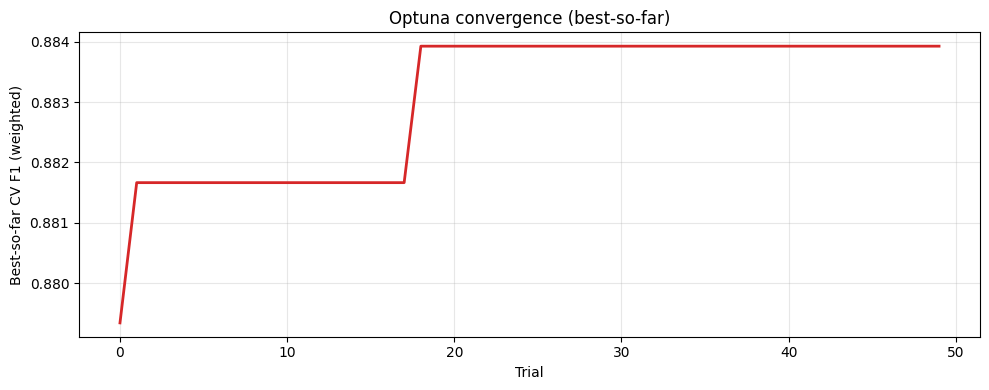

In [46]:
df_hist = study.trials_dataframe()
df_hist = df_hist.sort_values("number")

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"], marker="o", ms=3, alpha=0.7)
plt.xlabel("Trial")
plt.ylabel("CV mean F1 (weighted)")
plt.title("Optuna optimization history")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"].cummax(), color="tab:red", lw=2)
plt.xlabel("Trial")
plt.ylabel("Best-so-far CV F1 (weighted)")
plt.title("Optuna convergence (best-so-far)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [47]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

f1w = f1_score(y_test, y_pred, average="weighted")
kappa = cohen_kappa_score(y_test, y_pred)
print(f"F1 (weighted): {f1w:.4f}")
print(f"Cohen kappa:   {kappa:.4f}")


              precision    recall  f1-score   support

       anger       0.95      0.91      0.93      1165
     disgust       0.86      0.90      0.88      1164
        fear       0.88      0.87      0.88      1165
       happy       0.88      0.87      0.88      1164
     neutral       0.81      0.84      0.83       989
         sad       0.89      0.87      0.88      1164

    accuracy                           0.88      6811
   macro avg       0.88      0.88      0.88      6811
weighted avg       0.88      0.88      0.88      6811

F1 (weighted): 0.8795
Cohen kappa:   0.8549


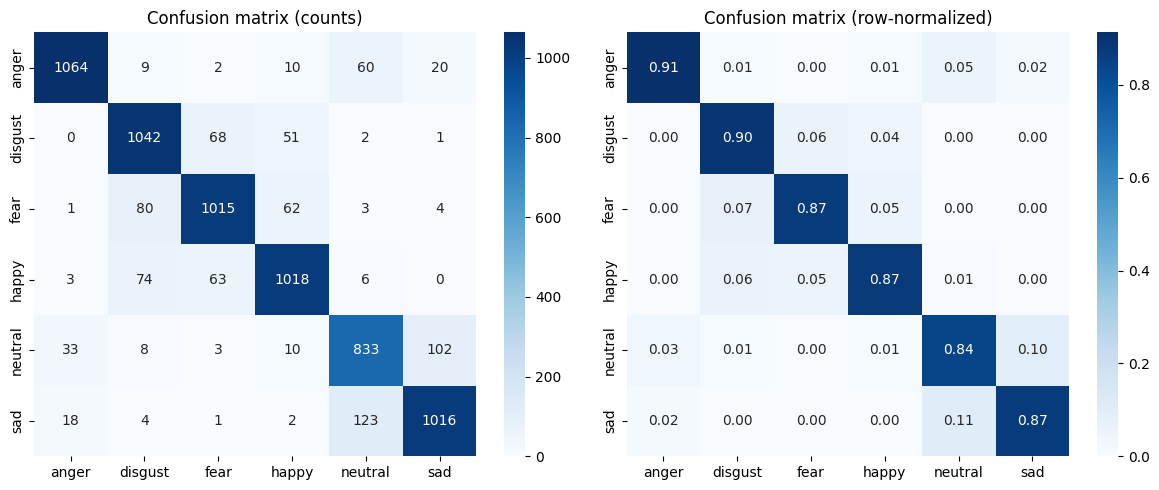

In [48]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title("Confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()
